In [1]:
!pip install transformers

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class HybridBERT_IDS(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(HybridBERT_IDS, self).__init__()

        self.bert = BertModel.from_pretrained('bert-base-uncased')

        for param in self.bert.parameters():
            param.requires_grad = False

        self.dnn = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_summary = bert_outputs.pooler_output
        logits = self.dnn(cls_summary)
        return logits

print("Downloading weights...")
model = HybridBERT_IDS().to(device)
print(model.dnn)

Using device: cuda 🚀


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- MODEL BUILT SUCCESSFULLY! ---
Sequential(
  (0): Linear(in_features=768, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import torch
from tqdm import tqdm

print("1. Preparing the Data for Training...")
df = pd.read_csv('/content/drive/MyDrive/Sem6/minor-project/bert-hybrid/ecu_ioht_clean.csv')

X_train, X_test, y_train, y_test = train_test_split(
    df['bert_text'].to_numpy(),
    df['label'].to_numpy(),
    test_size=0.2,
    random_state=42
)

class IDS_Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = IDS_Dataset(X_train, y_train, tokenizer)
test_dataset = IDS_Dataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("2. Setting up the Teacher (Optimizer & Loss Function)...")
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

print("3. Starting the Training Loop ")
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).unsqueeze(1)

        optimizer.zero_grad()
        predictions = model(input_ids, attention_mask)
        loss = criterion(predictions, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch {epoch+1} Complete! Average Training Loss: {avg_loss:.4f}\n")

torch.save(model.state_dict(), '/content/drive/MyDrive/Sem6/minor-project/bert-hybrid/hybrid_bert_trained.pth')
print("Training Complete. Model saved as 'hybrid_bert_trained.pth'")

1. Preparing the Data for Training...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2. Setting up the Teacher (Optimizer & Loss Function)...
3. Starting the Training Loop 


...


Epoch 1 Complete! Average Training Loss: 0.2228



Epoch 2/3: 100%|██████████| 1173/1173 [02:34<00:00,  7.58it/s, Loss=0.0117]



Epoch 2 Complete! Average Training Loss: 0.0786



Epoch 3/3: 100%|██████████| 1173/1173 [02:37<00:00,  7.42it/s, Loss=0.1894]



Epoch 3 Complete! Average Training Loss: 0.0560

Training Complete. Model saved as 'hybrid_bert_trained.pth'


Testing the model...

Test Complete!

Classification Metrics:
Accuracy: 99.28%
Precision: 99.85%
Recall: 0.9870
F1 Score: 0.9927



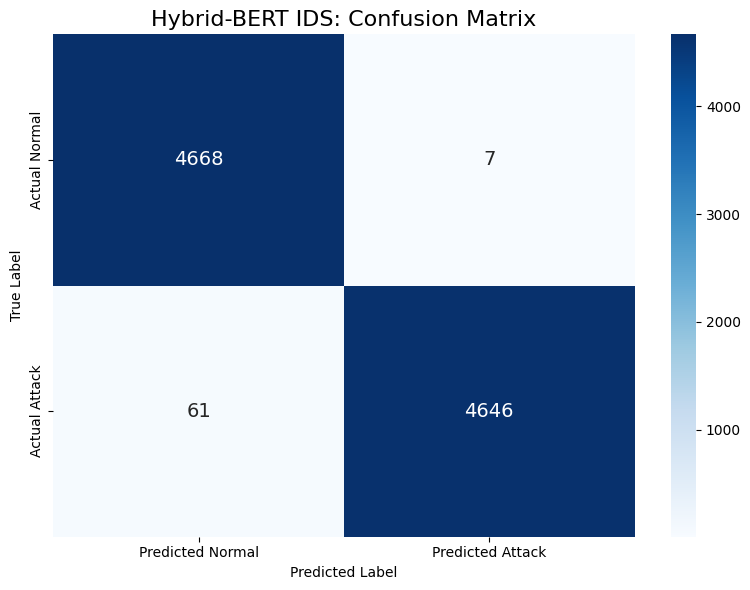

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Testing the model...")

model.eval()   # switch to evaluation mode (disables dropout)

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        probs = torch.sigmoid(outputs).squeeze()

        # handle both single and batch predictions
        if probs.dim() == 0:        # single item
            preds = [1 if probs.item() > 0.5 else 0]
        else:
            preds = [1 if p > 0.5 else 0 for p in probs.cpu().numpy()]

        all_predictions.extend(preds)
        all_true_labels.extend(labels.cpu().numpy())

print("\nTest Complete!\n")

# Calculate metrics from the paper
acc = accuracy_score(all_true_labels, all_predictions)
prec = precision_score(all_true_labels, all_predictions)
rec = recall_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions)

# Print human-readable metrics line-by-line
print("Classification Metrics:")
print(f"Accuracy: {(acc*100):.2f}%")
print(f"Precision: {(prec*100):.2f}%")
print(f"Recall: {(rec):.4f}")
print(f"F1 Score: {f1:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            annot_kws={"size": 14})

plt.title('Hybrid-BERT IDS: Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()